# Phase 2: Unsupervised Discovery (Topic Modeling)

## set up

In [ ]:
# Import necessary libraries
import matplotlib.pyplot as plt
import matplotlib.font_manager as fm
import seaborn as sns

# Setup Thai font for matplotlib
!wget -q -O thsarabunnew-webfont.ttf https://github.com/PyThaiNLP/prachathai-67k/raw/master/thsarabunnew-webfont.ttf

fm.fontManager.addfont("thsarabunnew-webfont.ttf")
plt.rc('font', family='TH Sarabun New')

print("Setup complete. Libraries and models are ready.")

Setup complete. Libraries and models are ready.


In [ ]:
%pip install pythainlp gensim pyldavis

## load dataset

In [ ]:
from datasets import load_dataset

# thaipbs-news dataset (scraped)
tpbs_ds = load_dataset("szzs1693/nlp-thaipbs-news")

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


In [ ]:
tpbs_df = tpbs_ds['train'].to_pandas()
tpbs_df.head()

,url,title,categoryName,abstract,publishedTime,tags,content_html,content_text
0,https://www.thaipbs.or.th/news/content/355884,"""อาร์เจนตินา"" ประตูสู่ ลาตินอเมริกา โอกาส ""ยา...",เศรษฐกิจ,,2025-09-01 03:38:00,"[อาร์เจนตินา, ส่งออกสินค้าไทย, ตลาดส่งออกไทย, ...","<p><strong><em>""บัวโนสไอเรส"" เมืองหลวงของอาร์เ...","""บัวโนสไอเรส"" เมืองหลวงของอาร์เจนตินา ตั้งอยู่..."
1,https://www.thaipbs.or.th/news/content/356014,“เนื้อโคขุน” สุรินทร์ ของดีเมืองไทย รสชาตินุ่ม...,เศรษฐกิจ,,2025-09-02 04:43:00,"[เนื้อสุรินทร์, เนื้อโคขุน, เนื้อโค, โคขุน, จั...",<p><em><strong>“สีแดงอมชมพู ลายไขมันแทรกสวย” เ...,“สีแดงอมชมพู ลายไขมันแทรกสวย” เมื่อปรุงสุกจะได...
2,https://www.thaipbs.or.th/news/content/356017,เปิดนำเข้าพ่อแม่พันธุ์ไก่ “รมว.เกษตรฯ”ถก บอร์ด...,เศรษฐกิจ,“รมว.เกษตรฯ” ถกบอร์ดไข่ไก่ ยันผู้ประกอบการขอนำ...,2025-09-01 08:40:00,"[ไข่ไก่, พ่อพันธุ์แม่พันธุ์ไก่, นำเข้าพ่อแม่พั...",<p>วันนี้ ( 1 ก.ย.2568) นายอรรถกร ศิริลัทธยากร...,วันนี้ ( 1 ก.ย.2568) นายอรรถกร ศิริลัทธยากร รม...
3,https://www.thaipbs.or.th/news/content/356047,พณ.ดันอาเซียน–อินเดีย ทบทวนข้อตกลงการค้าเปิดทา...,เศรษฐกิจ,พาณิชย์ ถกรมว.อาเซียน-อินเดีย ดันทบทวนความตกลง...,2025-09-02 05:40:40,"[ความตกลงการค้าสินค้าอาเซียน–อินเดีย, อาเซียนอ...",<p>วันนี้ ( 2 ก.ย.2568) นายฉันทวิชญ์ ตัณฑสิทธิ...,วันนี้ ( 2 ก.ย.2568) นายฉันทวิชญ์ ตัณฑสิทธิ์ ร...
4,https://www.thaipbs.or.th/news/content/356067,ไทยส่งออกสัตว์น้ำได้ฉลุย หลังสหรัฐฯประกาศผ่านเ...,เศรษฐกิจ,ข่าวดี สหรัฐฯ ประกาศ ไทยผ่านเกณฑ์มาตรฐาน MMPA ...,2025-09-02 08:59:13,"[กรมประมง, ส่งออกสัตว์น้ำ, สินค้าสัตว์น้ำไทย, ...",<p>วันนี้ ( 2 ก.ย.2568) นายบัญชา สุขแก้ว อธิบด...,วันนี้ ( 2 ก.ย.2568) นายบัญชา สุขแก้ว อธิบดีกร...


## LDA

In [ ]:
from pythainlp.corpus.common import thai_words, thai_stopwords
from pythainlp.tokenize import Trie

# ----------------------------------
# Sometimes we want some word not to break into tokens
# which might broke token modeling (mistaken a subword as a topic)
# For example: กล้าธรรม may become กล้า / ธรรม when tokenize

# We can create a custom dict here, but we don't need to add every single word.
# Just look at the results, see if something looks wrong to be a topic

# Extend PyThaiNLP existing thai words corpus
custom_dict = set(thai_words())

trie = Trie(custom_dict)

# We also don't want Thai stop words to be a topic, even it is repeated a lot.
# PyThaiNLP has existing thai stop_words as well

stopwords = set(thai_stopwords())

EXTRA_STOPWORDS = ["ไทย", "ปี", "วันที่", "เรื่อง"]
for sw in EXTRA_STOPWORDS:
    stopwords.add(sw)

In [ ]:
# # Custom text modifications
tpbs_df['text'] = tpbs_df['content_text']
# tpbs_df['text'] = tpbs_df['content_text'].str.replace("ลบ.ม.", "ลูกบาศก์เมตร")
# tpbs_df['text'] = tpbs_df['content_text'].str.replace("มค.ก.", "ไมโครกรัม")
tpbs_df['text'] = tpbs_df['text'].str.replace(" จ.", " จังหวัด")
tpbs_df['text'] = tpbs_df['text'].str.replace(" อ.", " อำเภอ")

In [ ]:
from pythainlp.tokenize import word_tokenize

# Then we define a tokenize function
# with custom dict added, and filter tokens
# which aren't super short `len(t) > 1`
# and not in the stop_words

def tokenize(text):
    tokens = word_tokenize(text, engine='newmm', custom_dict=trie, keep_whitespace=False)
    return [
        t for t in tokens if t not in stopwords and len(t) > 1 and not t.isdigit()
    ]

# Merge and flatten all texts into a long list of tokens
# body_text is a column in the dataframe, change it to appropriate one
print("Tokenizing corpus...")
texts = [tokenize(t) for t in tpbs_df['text']]
print(f"Done. Avg tokens per doc: {sum(len(t) for t in texts)/len(texts):.0f}")

Tokenizing corpus...
Done. Avg tokens per doc: 280


In [ ]:
# Run LDA on the full corpus to see what topics emerge

from gensim import corpora
from gensim.models.coherencemodel import CoherenceModel
from gensim.models import LdaModel

dictionary = corpora.Dictionary(texts)

corpus = [dictionary.doc2bow(t) for t in texts]
print(f"Vocabulary size: {len(dictionary)}")

Vocabulary size: 22299


In [ ]:
lda = LdaModel(
    corpus, num_topics=5, id2word=dictionary,
    passes=10, random_state=42, alpha='auto', eta='auto'
)

# Compute Coherence Score
coherence_model_lda = CoherenceModel(model=lda, texts=texts, dictionary=dictionary, coherence='c_v')
coherence_lda = coherence_model_lda.get_coherence()
print(f'Coherence Score (c_v): {coherence_lda:.4f}')


print("\nTop 12 words per topic:")
for i, topic in lda.print_topics(num_words=12):
    words = [w.split('*')[1].strip('"') for w in topic.split(' + ')]
    print(f"  Topic {i + 1}: {', '.join(words)}")

Coherence Score (c_v): 0.5197

Top 12 words per topic:
  Topic 1: สินค้า, ล้าน, ประเทศ, เศรษฐกิจ, บาท, ตลาด, ข้าว, ราคา, เดือน, สหรัฐฯ, การค้า, จีน
  Topic 2: บาท, โครงการ, ประชาชน, ล้าน, ระบบ, สิทธิ, เดือน, ทองคำ, สำหรับ, ข้อมูล, เงิน, ราคา
  Topic 3: พรรค, เขต, สส., คน, พรรคภูมิใจไทย, พรรคเพื่อไทย, รัฐบาล, ประชาชน, ผู้สมัคร, พรรคประชาชน, จังหวัด, การเลือกตั้ง
  Topic 4: พื้นที่, เขต, จังหวัด, คน, แขวง, ประชาชน, อำเภอ, บริเวณ, คะแนน, น้ำ, น., พระ
  Topic 5: ประชาชน, กัมพูชา, การเลือกตั้ง, กกต., ประเทศ, คน, สิทธิ, เลือกตั้ง, พื้นที่, กรณี, ดำเนินการ, คณะกรรมการ


In [ ]:
lda = LdaModel(
    corpus, num_topics=6, id2word=dictionary,
    passes=10, random_state=42, alpha='auto', eta='auto'
)

# Compute Coherence Score
coherence_model_lda = CoherenceModel(model=lda, texts=texts, dictionary=dictionary, coherence='c_v')
coherence_lda = coherence_model_lda.get_coherence()
print(f'Coherence Score (c_v): {coherence_lda:.4f}')


print("\nTop 12 words per topic:")
for i, topic in lda.print_topics(num_words=12):
    words = [w.split('*')[1].strip('"') for w in topic.split(' + ')]
    print(f"  Topic {i + 1}: {', '.join(words)}")

Coherence Score (c_v): 0.5058

Top 12 words per topic:
  Topic 1: สินค้า, ล้าน, ตลาด, บาท, ข้าว, ประเทศ, เศรษฐกิจ, ราคา, เดือน, สหรัฐฯ, การค้า, จีน
  Topic 2: บาท, โครงการ, ประชาชน, ล้าน, เดือน, ทองคำ, ระบบ, สิทธิ, เงิน, ราคา, สำหรับ, คนละ
  Topic 3: พรรค, เขต, สส., คน, พรรคภูมิใจไทย, พรรคเพื่อไทย, ผู้สมัคร, ประชาชน, รัฐบาล, จังหวัด, พรรคประชาชน, เลือกตั้ง
  Topic 4: พื้นที่, เขต, จังหวัด, ประชาชน, แขวง, บริเวณ, คน, อำเภอ, น้ำ, น., พระ, ถนน
  Topic 5: ประชาชน, กัมพูชา, การเลือกตั้ง, กกต., เลือกตั้ง, ประเทศ, สิทธิ, คน, กรณี, พื้นที่, ดำเนินการ, คณะกรรมการ
  Topic 6: ประเทศ, สร้าง, คน, เศรษฐกิจ, พื้นที่, ธุรกิจ, การพัฒนา, ประชาชน, ข้อมูล, สังคม, AI, เด็ก


In [ ]:
lda = LdaModel(
    corpus, num_topics=7, id2word=dictionary,
    passes=10, random_state=42, alpha='auto', eta='auto'
)

# Compute Coherence Score
coherence_model_lda = CoherenceModel(model=lda, texts=texts, dictionary=dictionary, coherence='c_v')
coherence_lda = coherence_model_lda.get_coherence()
print(f'Coherence Score (c_v): {coherence_lda:.4f}')


print("\nTop 12 words per topic:")
for i, topic in lda.print_topics(num_words=12):
    words = [w.split('*')[1].strip('"') for w in topic.split(' + ')]
    print(f"  Topic {i + 1}: {', '.join(words)}")

Coherence Score (c_v): 0.4987

Top 12 words per topic:
  Topic 1: สินค้า, ล้าน, ตลาด, ข้าว, ประเทศ, บาท, เศรษฐกิจ, ราคา, การค้า, สหรัฐฯ, เดือน, จีน
  Topic 2: บาท, โครงการ, ประชาชน, ล้าน, ทองคำ, ราคา, สิทธิ, ระบบ, สำหรับ, เดือน, คนละ, เงิน
  Topic 3: พรรค, เขต, สส., คน, พรรคภูมิใจไทย, พรรคเพื่อไทย, ผู้สมัคร, จังหวัด, รัฐบาล, คะแนน, ประชาชน, เลือกตั้ง
  Topic 4: พื้นที่, จังหวัด, เขต, แขวง, ประชาชน, บริเวณ, น้ำ, คน, น., พระ, อำเภอ, ถนน
  Topic 5: ประชาชน, กัมพูชา, การเลือกตั้ง, กกต., ประเทศ, เลือกตั้ง, สิทธิ, คน, กรณี, พื้นที่, รัฐบาล, ทำ
  Topic 6: ประเทศ, สร้าง, คน, เศรษฐกิจ, ธุรกิจ, พื้นที่, ประชาชน, AI, การพัฒนา, ข้อมูล, เทคโนโลยี, นโยบาย
  Topic 7: ตรวจสอบ, คน, บัญชี, ข้อมูล, เงิน, คดี, คณะกรรมการ, จำนวน, สอบ, กรณี, ดำเนินการ, ประชาชน


In [ ]:
lda = LdaModel(
    corpus, num_topics=8, id2word=dictionary,
    passes=10, random_state=42, alpha='auto', eta='auto'
)

# Compute Coherence Score
coherence_model_lda = CoherenceModel(model=lda, texts=texts, dictionary=dictionary, coherence='c_v')
coherence_lda = coherence_model_lda.get_coherence()
print(f'Coherence Score (c_v): {coherence_lda:.4f}')


print("\nTop 12 words per topic:")
for i, topic in lda.print_topics(num_words=12):
    words = [w.split('*')[1].strip('"') for w in topic.split(' + ')]
    print(f"  Topic {i + 1}: {', '.join(words)}")

Coherence Score (c_v): 0.5109

Top 12 words per topic:
  Topic 1: สินค้า, ล้าน, ตลาด, ข้าว, บาท, ประเทศ, เศรษฐกิจ, ราคา, การค้า, สหรัฐฯ, เดือน, จีน
  Topic 2: บาท, โครงการ, ล้าน, ประชาชน, ทองคำ, ราคา, เดือน, สิทธิ, สำหรับ, คนละ, เงิน, ครึ่ง
  Topic 3: พรรค, เขต, สส., คน, พรรคภูมิใจไทย, พรรคเพื่อไทย, ผู้สมัคร, คะแนน, จังหวัด, เลือกตั้ง, รัฐบาล, ประชาชน
  Topic 4: พื้นที่, เขต, แขวง, ประชาชน, น้ำ, จังหวัด, น., บริเวณ, พระ, ถนน, คน, จุด
  Topic 5: การเลือกตั้ง, ประชาชน, กกต., เลือกตั้ง, คน, สิทธิ, รัฐบาล, สส., ประเทศ, กรณี, ทำ, ก.พ.
  Topic 6: ประเทศ, สร้าง, เศรษฐกิจ, ธุรกิจ, การพัฒนา, พื้นที่, คน, นโยบาย, AI, เทคโนโลยี, ทำ, รัฐบาล
  Topic 7: ตรวจสอบ, คน, คดี, สอบ, คณะกรรมการ, สินค้า, ข้อมูล, จำนวน, พ.ศ., ดำเนินการ, กรณี, มาตรา
  Topic 8: กัมพูชา, พื้นที่, จังหวัด, ชายแดน, สถานการณ์, ประชาชน, ทหาร, โรค, คน, ระบุ, โรงเรียน, ประเทศ


In [ ]:
lda = LdaModel(
    corpus, num_topics=9, id2word=dictionary,
    passes=10, random_state=42, alpha='auto', eta='auto'
)

# Compute Coherence Score
coherence_model_lda = CoherenceModel(model=lda, texts=texts, dictionary=dictionary, coherence='c_v')
coherence_lda = coherence_model_lda.get_coherence()
print(f'Coherence Score (c_v): {coherence_lda:.4f}')


print("\nTop 12 words per topic:")
for i, topic in lda.print_topics(num_words=12):
    words = [w.split('*')[1].strip('"') for w in topic.split(' + ')]
    print(f"  Topic {i + 1}: {', '.join(words)}")

Coherence Score (c_v): 0.4963

Top 12 words per topic:
  Topic 1: สินค้า, ล้าน, ตลาด, ข้าว, บาท, ประเทศ, ราคา, เศรษฐกิจ, การค้า, สหรัฐฯ, เดือน, ลด
  Topic 2: บาท, โครงการ, ล้าน, ประชาชน, ทองคำ, ราคา, เดือน, คนละ, ครึ่ง, สำหรับ, สิทธิ, ระบบ
  Topic 3: เขต, คน, บาท, สส., รมว., คณะกรรมการ, พรรคภูมิใจไทย, ประชาชน, โครงการ, จังหวัด, อนุทิน, กรณี
  Topic 4: พื้นที่, เขต, แขวง, น้ำ, ประชาชน, บริเวณ, น., ถนน, จังหวัด, พระ, จุด, เจ้าหน้าที่
  Topic 5: การเลือกตั้ง, ประชาชน, กกต., เลือกตั้ง, สิทธิ, กัมพูชา, ประเทศ, คน, กรณี, ก.พ., ดำเนินการ, สส.
  Topic 6: เศรษฐกิจ, ประเทศ, สร้าง, ธุรกิจ, การพัฒนา, รัฐบาล, เทคโนโลยี, AI, นโยบาย, ประชาชน, คน, จีน
  Topic 7: ตรวจสอบ, คดี, ข้อมูล, สอบ, คน, สินค้า, คณะกรรมการ, กรม, มาตรา, จำนวน, พ.ศ., ดำเนินการ
  Topic 8: กัมพูชา, พื้นที่, โรค, คน, เงิน, ทหาร, บัญชี, ประชาชน, สถานการณ์, ควบคุม, ร้อยละ, ระบุ
  Topic 9: พรรค, เขต, สส., คน, พื้นที่, จังหวัด, ประชาชน, พรรคเพื่อไทย, พรรคภูมิใจไทย, คะแนน, พรรคประชาชน, ผู้สมัคร


In [ ]:
lda = LdaModel(
    corpus, num_topics=10, id2word=dictionary,
    passes=10, random_state=42, alpha='auto', eta='auto'
)

# Compute Coherence Score
coherence_model_lda = CoherenceModel(model=lda, texts=texts, dictionary=dictionary, coherence='c_v')
coherence_lda = coherence_model_lda.get_coherence()
print(f'Coherence Score (c_v): {coherence_lda:.4f}')


print("\nTop 12 words per topic:")
for i, topic in lda.print_topics(num_words=12):
    words = [w.split('*')[1].strip('"') for w in topic.split(' + ')]
    print(f"  Topic {i + 1}: {', '.join(words)}")

Coherence Score (c_v): 0.4751

Top 12 words per topic:
  Topic 1: สินค้า, ล้าน, ตลาด, ข้าว, ประเทศ, บาท, เศรษฐกิจ, ราคา, การค้า, สหรัฐฯ, เดือน, จีน
  Topic 2: บาท, โครงการ, ประชาชน, ล้าน, ทองคำ, ราคา, สิทธิ, คนละ, ครึ่ง, สำหรับ, เดือน, ระบบ
  Topic 3: เขต, คน, สส., พรรค, พรรคภูมิใจไทย, บาท, รัฐบาล, รมว., อนุทิน, ประชาชน, ร้อยละ, ผู้สมัคร
  Topic 4: พื้นที่, เขต, แขวง, น้ำ, ประชาชน, ถนน, บริเวณ, พระ, น., จุด, จังหวัด, กรุงเทพมหานคร
  Topic 5: การเลือกตั้ง, กกต., ประชาชน, เลือกตั้ง, สิทธิ, คน, รัฐบาล, สส., ก.พ., ประเทศ, คณะกรรมการ, มาตรา
  Topic 6: ธุรกิจ, เศรษฐกิจ, ประเทศ, สร้าง, การพัฒนา, คน, อุตสาหกรรม, พื้นที่, ประชาชน, รัฐบาล, กุ้ง, ยา
  Topic 7: ตรวจสอบ, สินค้า, คดี, คน, กรม, คณะกรรมการ, ดำเนินการ, ข้อมูล, พ.ศ., ตำรวจ, ปราบปราม, ประชาชน
  Topic 8: กัมพูชา, พื้นที่, ชายแดน, ทหาร, สถานการณ์, ประเทศ, ประชาชน, โรค, จังหวัด, ระบุ, คน, เงิน
  Topic 9: พรรค, สส., เขต, คน, พื้นที่, จังหวัด, ประชาชน, คะแนน, พรรคเพื่อไทย, ผู้สมัคร, พรรคประชาชน, พรรคภูมิใจไทย
  Topic 10: ลบ, ก., ม., สอบ, มค, 

## CHOSEN NUMBER OF TOPICS : 5

In [ ]:
lda = LdaModel(
    corpus, num_topics=5, id2word=dictionary,
    passes=10, random_state=42, alpha='auto', eta='auto'
)

# Compute Coherence Score
coherence_model_lda = CoherenceModel(model=lda, texts=texts, dictionary=dictionary, coherence='c_v')
coherence_lda = coherence_model_lda.get_coherence()
print(f'Coherence Score (c_v): {coherence_lda:.4f}')


print("\nTop 12 words per topic:")
for i, topic in lda.print_topics(num_words=12):
    words = [w.split('*')[1].strip('"') for w in topic.split(' + ')]
    print(f"  Topic {i + 1}: {', '.join(words)}")

Coherence Score (c_v): 0.5197

Top 12 words per topic:
  Topic 1: สินค้า, ล้าน, ประเทศ, เศรษฐกิจ, บาท, ตลาด, ข้าว, ราคา, เดือน, สหรัฐฯ, การค้า, จีน
  Topic 2: บาท, โครงการ, ประชาชน, ล้าน, ระบบ, สิทธิ, เดือน, ทองคำ, สำหรับ, ข้อมูล, เงิน, ราคา
  Topic 3: พรรค, เขต, สส., คน, พรรคภูมิใจไทย, พรรคเพื่อไทย, รัฐบาล, ประชาชน, ผู้สมัคร, พรรคประชาชน, จังหวัด, การเลือกตั้ง
  Topic 4: พื้นที่, เขต, จังหวัด, คน, แขวง, ประชาชน, อำเภอ, บริเวณ, คะแนน, น้ำ, น., พระ
  Topic 5: ประชาชน, กัมพูชา, การเลือกตั้ง, กกต., ประเทศ, คน, สิทธิ, เลือกตั้ง, พื้นที่, กรณี, ดำเนินการ, คณะกรรมการ


จากการคำนวณ พบว่า ค่า Coherence Score ที่มีค่าสูงที่สุด อยู่ที่ 0.5197 โดยมี K = 5  จึงสรุปได้ว่า จำนวน Topic ที่เหมาะสมที่สุดคือ 5
โดย
- Topic 1 มีคำว่า สินค้า, ตลาด, ข้าว, ราคา, เศรษฐกิจ จึงอนุมานได้ว่า Topic นี้ พูดถึงเรื่อง การค้า

- Topic 2 มีคำว่า โครงการ, ทองคำ, เงิน, ราคา, ระบบ, สิทธิ จึงอนุมานได้ว่า Topic นี้ พูดถึงเรื่อง เศรษฐกิจ
- Topic 3 มีคำว่า พรรค, เขต, สส., รัฐบาล จึงอนุมานได้ว่า Topic นี้ พูดถึงเรื่อง การเมือง
- Topic 4 มีคำว่า พื้นที่, เขต, จังหวัด, แขวง, อำเภอ, บริเวณ จึงอนุมานได้ว่า Topic นี้ พูดถึงเรื่อง ภูมิภาค
- Topic 5 มีคำว่า ประชาชน, การเลือกตั้ง, กกต., ประเทศ, คน, สิทธิ, เลือกตั้ง จึงอนุมานได้ว่า Topic นี้ พูดถึงเรื่อง การเลือกตั้ง

## Visualizations

In [ ]:
import pyLDAvis
import pyLDAvis.gensim_models as gensimvis

pyLDAvis.enable_notebook()
vis = gensimvis.prepare(lda, corpus, dictionary, sort_topics=False)
pyLDAvis.display(vis)

/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)


/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)


/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packag

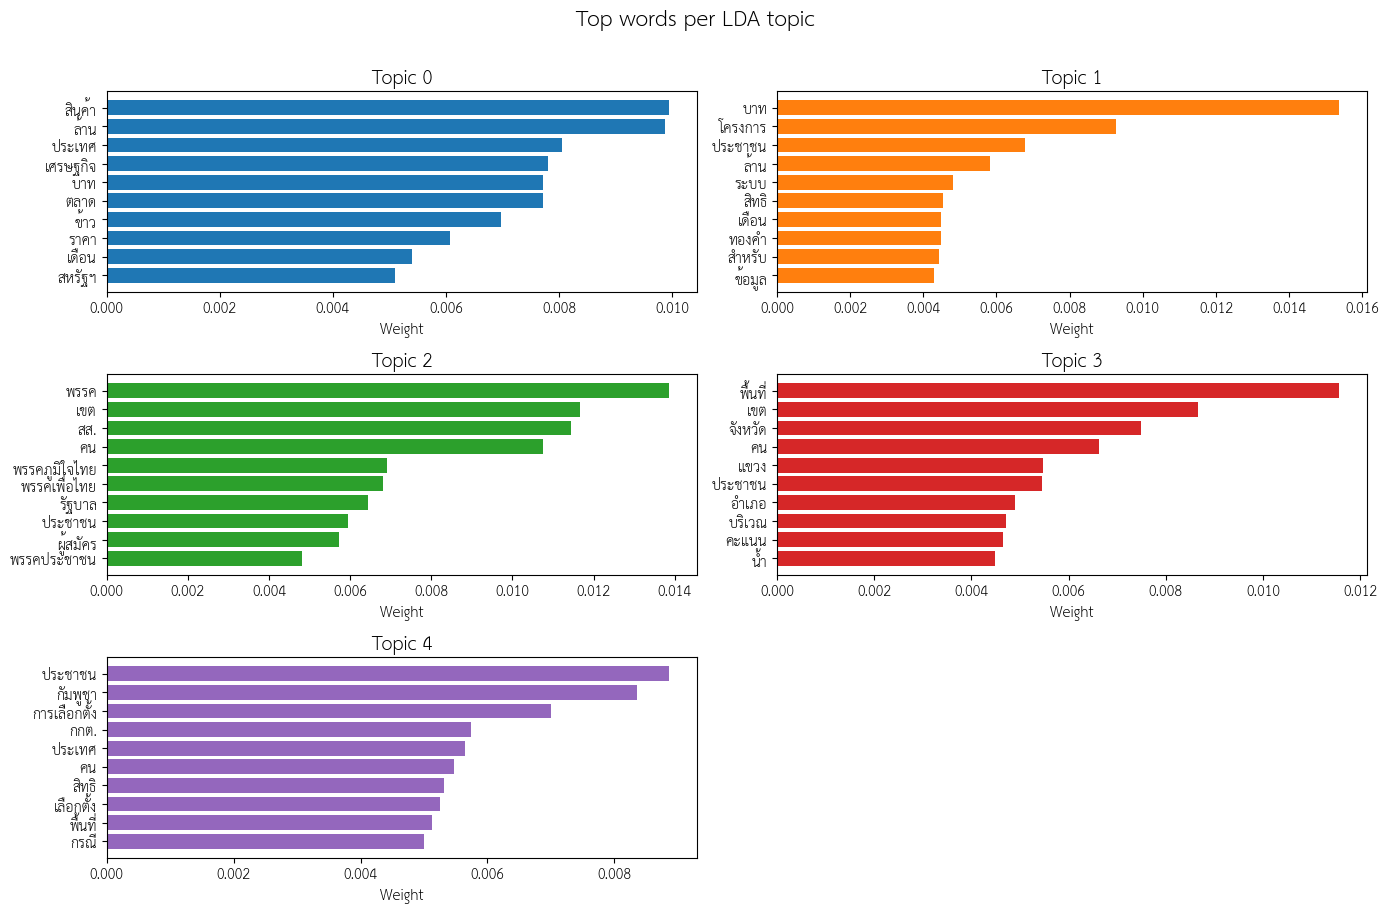

/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packag

In [ ]:
# Top words per topic — horizontal bar charts
NUM_WORDS = 10
num_topics = lda.num_topics

fig, axes = plt.subplots(nrows=(num_topics + 1) // 2, ncols=2, figsize=(14, 3 * ((num_topics + 1) // 2)))
axes = axes.flatten()

for i in range(num_topics):
    topic_terms = lda.show_topic(i, topn=NUM_WORDS)
    words = [w for w, _ in reversed(topic_terms)]
    weights = [p for _, p in reversed(topic_terms)]
    axes[i].barh(words, weights, color=f"C{i}")
    axes[i].set_title(f"Topic {i}", fontsize=13)
    axes[i].set_xlabel("Weight")

# Hide any unused subplot
for j in range(num_topics, len(axes)):
    axes[j].set_visible(False)

plt.suptitle("Top words per LDA topic", fontsize=15, y=1.01)
plt.tight_layout()
plt.show()

/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packag

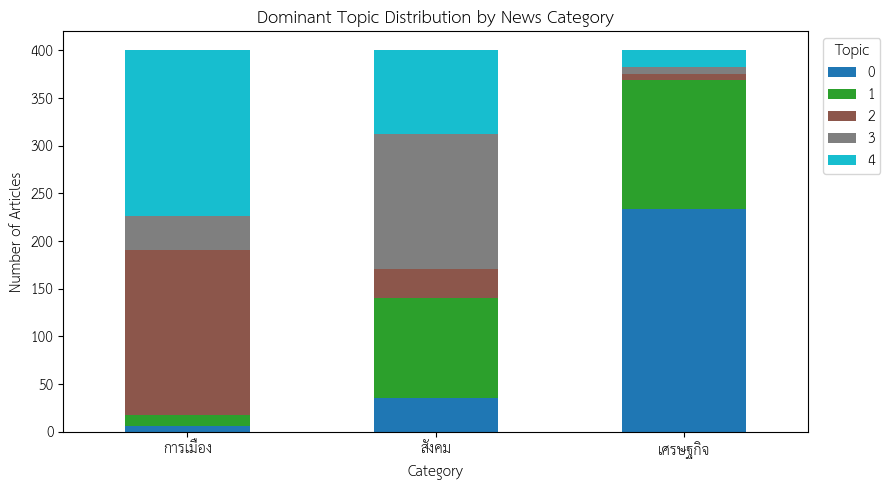

/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packag

In [ ]:
# Dominant topic per document — distribution by news category
def dominant_topic(bow):
    topics = lda.get_document_topics(bow)
    return max(topics, key=lambda x: x[1])[0]

tpbs_df['dominant_topic'] = [dominant_topic(bow) for bow in corpus]

# Stacked bar: how each category's articles distribute across topics
pivot = tpbs_df.groupby(['categoryName', 'dominant_topic']).size().unstack(fill_value=0)
pivot.plot(kind='bar', stacked=True, figsize=(9, 5), colormap='tab10')
plt.title("Dominant Topic Distribution by News Category")
plt.xlabel("Category")
plt.ylabel("Number of Articles")
plt.legend(title="Topic", bbox_to_anchor=(1.01, 1), loc='upper left')
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

In [ ]:
# Inspect articles containing a specific token
# Change this to the token you want to investigate
INSPECT_TOKEN = "อ."

matches = [
    (i, tpbs_df.iloc[i]['title'], tpbs_df.iloc[i]['categoryName'], tpbs_df.iloc[i]['dominant_topic'], texts[i])
    for i in range(len(texts))
    if INSPECT_TOKEN in texts[i]
]

print(f"Found {len(matches)} articles containing '{INSPECT_TOKEN}':\n")
for idx, title, category, topic, tokens in matches[:10]:
    surrounding = []
    for j, t in enumerate(tokens):
        if t == INSPECT_TOKEN:
            surrounding.append(tokens[max(0, j-3):j+4])
    print(f"[{idx}] Topic {topic} | {category}")
    print(f"  Title: {title}")
    for ctx in surrounding[:3]:
        print(f"  Context: {' / '.join(ctx)}")
    print()

Found 95 articles containing 'อ.':

[12] Topic 1 | เศรษฐกิจ
  Title: ผู้ค้า-เอกชนหนุนรับ "คนละครึ่ง" หวังกระตุ้นเศรษฐกิจปลายปี
  Context: ครึ่ง / รัฐบาล / พล / อ. / ประยุทธ์ / จันทร์ / โอชา

[19] Topic 4 | เศรษฐกิจ
  Title: บอร์ด สมอ. ไฟเขียว “วงล้อรถยนต์” สินค้าควบคุม มีผลปี 69
  Context: ผลิตภัณฑ์ / อุตสาหกรรม / กม / อ. / มติ / การประชุม / บอร์ด
  Context: ผลิตภัณฑ์ / อุตสาหกรรม / กม / อ. / เห็นชอบ / วง / ล้อ

[48] Topic 1 | เศรษฐกิจ
  Title: "อนุทิน" ลั่นนำ "คนละครึ่ง" กลับมาใช้ คาดเร็วสุดกลาง ต.ค.นี้
  Context: เทียบ / รัฐบาล / พล / อ. / ประยุทธ์ / จันทร์ / โอชา

[91] Topic 0 | เศรษฐกิจ
  Title: กนง.มีมติ 5:2 เสียง คงอัตราดอกเบี้ยนโยบายที่ 1.50% ต่อปี 
  Context: เทียบ / ดอลลาร์ / สร / อ. / เคลื่อนไหว / แข็งค่า / จังหวะ

[99] Topic 1 | เศรษฐกิจ
  Title: คุม "ราคายา-เวชภัณฑ์" ช่วยค่าครองชีพ ไม่ใหม่ แต่ "คนไทย" ต้องรู้
  Context: ยา / รัฐบาล / พล / อ. / ประยุทธ์ / จันทร์ / โอชา

[104] Topic 4 | เศรษฐกิจ
  Title: TMAC ส่งชุดเครื่องจักรกวาดล้างทุ่นระเบิด หนุนกองกำลังบูรพา  
  Context: 

/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packag

In [ ]:
print("Topic distributions (top 15 words with probabilities):")
for i in range(lda.num_topics):
    print(f"Topic {i}:")
    topic_terms = lda.show_topic(i, topn=15)
    for word, prob in topic_terms:
        print(f"  - {word}: {prob:.4f}")

/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packag

Topic distributions (top 15 words with probabilities):
Topic 0:
  - สินค้า: 0.0099
  - ล้าน: 0.0099
  - ประเทศ: 0.0081
  - เศรษฐกิจ: 0.0078
  - บาท: 0.0077
  - ตลาด: 0.0077
  - ข้าว: 0.0070
  - ราคา: 0.0061
  - เดือน: 0.0054
  - สหรัฐฯ: 0.0051
  - การค้า: 0.0050
  - จีน: 0.0049
  - ลด: 0.0047
  - สร้าง: 0.0046
  - มาตรการ: 0.0044
Topic 1:
  - บาท: 0.0154
  - โครงการ: 0.0093
  - ประชาชน: 0.0068
  - ล้าน: 0.0058
  - ระบบ: 0.0048
  - สิทธิ: 0.0045
  - เดือน: 0.0045
  - ทองคำ: 0.0045
  - สำหรับ: 0.0044
  - ข้อมูล: 0.0043
  - เงิน: 0.0042
  - ราคา: 0.0041
  - พื้นที่: 0.0039
  - คนละ: 0.0039
  - คน: 0.0038
Topic 2:
  - พรรค: 0.0139
  - เขต: 0.0117
  - สส.: 0.0114
  - คน: 0.0107
  - พรรคภูมิใจไทย: 0.0069
  - พรรคเพื่อไทย: 0.0068
  - รัฐบาล: 0.0064
  - ประชาชน: 0.0060
  - ผู้สมัคร: 0.0057
  - พรรคประชาชน: 0.0048
  - จังหวัด: 0.0046
  - การเลือกตั้ง: 0.0045
  - เลือกตั้ง: 0.0043
  - นโยบาย: 0.0041
  - พื้นที่: 0.0038
Topic 3:
  - พื้นที่: 0.0116
  - เขต: 0.0087
  - จังหวัด: 0.0075
  - คน: 0.00

/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packag